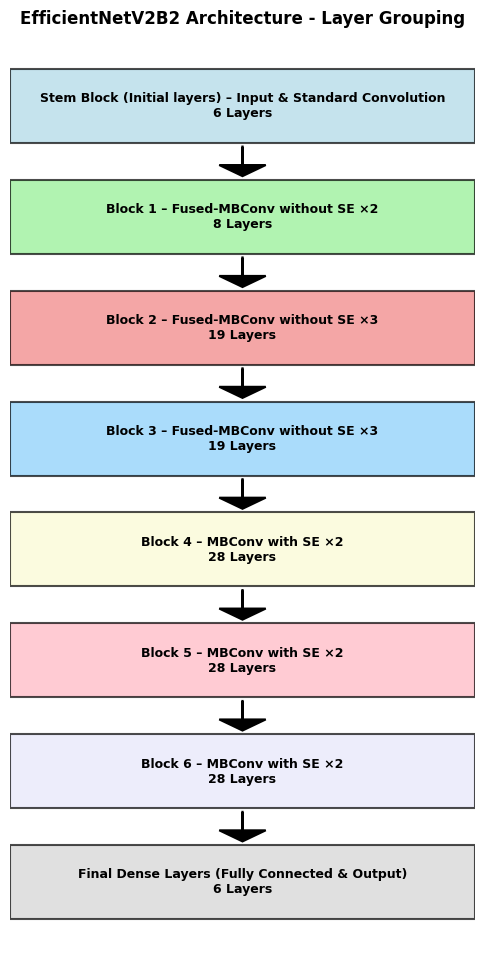

In [92]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Define grouped layers
layer_groups = {
    # Standard convolution block (NOT Fused-MBConv)
    "Stem Block (Initial layers) – Input & Standard Convolution": [
        "input_layer_1", "rescaling_1", "normalization_1",
        "stem_conv", "stem_bn", "stem_activation"
    ],

    # Fused-MBConv without SE x2 (Confirmed from EfficientNetV2B2 structure)
    "Block 1 – Fused-MBConv without SE ×2": [
        "block1a_project_conv", "block1a_project_bn", "block1a_project_activation",
        "block1b_project_conv", "block1b_project_bn", "block1b_project_activation",
        "block1b_drop", "block1b_add"
    ],

    # Fused-MBConv without SE x3
    "Block 2 – Fused-MBConv without SE ×3": [
        "block2a_expand_conv", "block2a_expand_bn", "block2a_expand_activation",
        "block2a_project_conv", "block2a_project_bn",
        "block2b_expand_conv", "block2b_expand_bn", "block2b_expand_activation",
        "block2b_project_conv", "block2b_project_bn", "block2b_drop", "block2b_add",
        "block2c_expand_conv", "block2c_expand_bn", "block2c_expand_activation",
        "block2c_project_conv", "block2c_project_bn", "block2c_drop", "block2c_add"
    ],

    # Fused-MBConv without SE x3
    "Block 3 – Fused-MBConv without SE ×3": [
        "block3a_expand_conv", "block3a_expand_bn", "block3a_expand_activation",
        "block3a_project_conv", "block3a_project_bn",
        "block3b_expand_conv", "block3b_expand_bn", "block3b_expand_activation",
        "block3b_project_conv", "block3b_project_bn", "block3b_drop", "block3b_add",
        "block3c_expand_conv", "block3c_expand_bn", "block3c_expand_activation",
        "block3c_project_conv", "block3c_project_bn", "block3c_drop", "block3c_add"
    ],

    # MBConv with SE x2 – includes SE layers (squeeze/excite)
    "Block 4 – MBConv with SE ×2": [
        "block4a_expand_conv", "block4a_expand_bn", "block4a_expand_activation",
        "block4a_dwconv2", "block4a_bn", "block4a_activation",
        "block4a_se_squeeze", "block4a_se_reshape", "block4a_se_reduce", "block4a_se_expand", "block4a_se_excite",
        "block4a_project_conv", "block4a_project_bn",
        "block4b_expand_conv", "block4b_expand_bn", "block4b_expand_activation",
        "block4b_dwconv2", "block4b_bn", "block4b_activation",
        "block4b_se_squeeze", "block4b_se_reshape", "block4b_se_reduce", "block4b_se_expand", "block4b_se_excite",
        "block4b_project_conv", "block4b_project_bn", "block4b_drop", "block4b_add"
    ],

    # MBConv with SE x2
    "Block 5 – MBConv with SE ×2": [
        "block5a_expand_conv", "block5a_expand_bn", "block5a_expand_activation",
        "block5a_dwconv2", "block5a_bn", "block5a_activation",
        "block5a_se_squeeze", "block5a_se_reshape", "block5a_se_reduce", "block5a_se_expand", "block5a_se_excite",
        "block5a_project_conv", "block5a_project_bn",
        "block5b_expand_conv", "block5b_expand_bn", "block5b_expand_activation",
        "block5b_dwconv2", "block5b_bn", "block5b_activation",
        "block5b_se_squeeze", "block5b_se_reshape", "block5b_se_reduce", "block5b_se_expand", "block5b_se_excite",
        "block5b_project_conv", "block5b_project_bn", "block5b_drop", "block5b_add"
    ],

    # MBConv with SE x2
    "Block 6 – MBConv with SE ×2": [
        "block6a_expand_conv", "block6a_expand_bn", "block6a_expand_activation",
        "block6a_dwconv2", "block6a_bn", "block6a_activation",
        "block6a_se_squeeze", "block6a_se_reshape", "block6a_se_reduce", "block6a_se_expand", "block6a_se_excite",
        "block6a_project_conv", "block6a_project_bn",
        "block6b_expand_conv", "block6b_expand_bn", "block6b_expand_activation",
        "block6b_dwconv2", "block6b_bn", "block6b_activation",
        "block6b_se_squeeze", "block6b_se_reshape", "block6b_se_reduce", "block6b_se_expand", "block6b_se_excite",
        "block6b_project_conv", "block6b_project_bn", "block6b_drop", "block6b_add"
    ],

    # Final classifier
    "Final Dense Layers (Fully Connected & Output)": [
        "top_conv", "top_bn", "top_activation", "avg_pool", "top_dropout",
        "predictions (Final Softmax Layer)"
    ]
}


# Plotting
fig, ax = plt.subplots(figsize=(6, 12))
y_offset = len(layer_groups) * 3  # Start from top

colors = ["lightblue", "lightgreen", "lightcoral", "lightskyblue", "lightgoldenrodyellow",
          "lightpink", "lavender", "lightgray"]

# Draw blocks
for i, (group_name, layers) in enumerate(layer_groups.items()):
    group_height = 2  # Fixed height for each block
    rect = patches.Rectangle((0, y_offset), 3, -group_height, linewidth=1.5,
                             edgecolor='black', facecolor=colors[i % len(colors)], alpha=0.7)
    ax.add_patch(rect)

    # Text for Group Names
    ax.text(1.5, y_offset - group_height / 2, f"{group_name}\n{len(layers)} Layers",
            ha='center', va='center', fontsize=9, fontweight='bold')

    # Add arrows between blocks
    if i < len(layer_groups) - 1:
        ax.arrow(1.5, y_offset - group_height - 0.1, 0, -0.5, head_width=0.3, head_length=0.3,
                 fc="black", ec="black", linewidth=1.5)

    y_offset -= group_height + 1  # Adjust spacing

ax.set_xlim(0, 3)
ax.set_ylim(0, len(layer_groups) * 3 + 1)
ax.set_xticks([])
ax.set_yticks([])
ax.set_frame_on(False)

# Title
plt.title("EfficientNetV2B2 Architecture - Layer Grouping", fontsize=12, fontweight='bold')
plt.show()


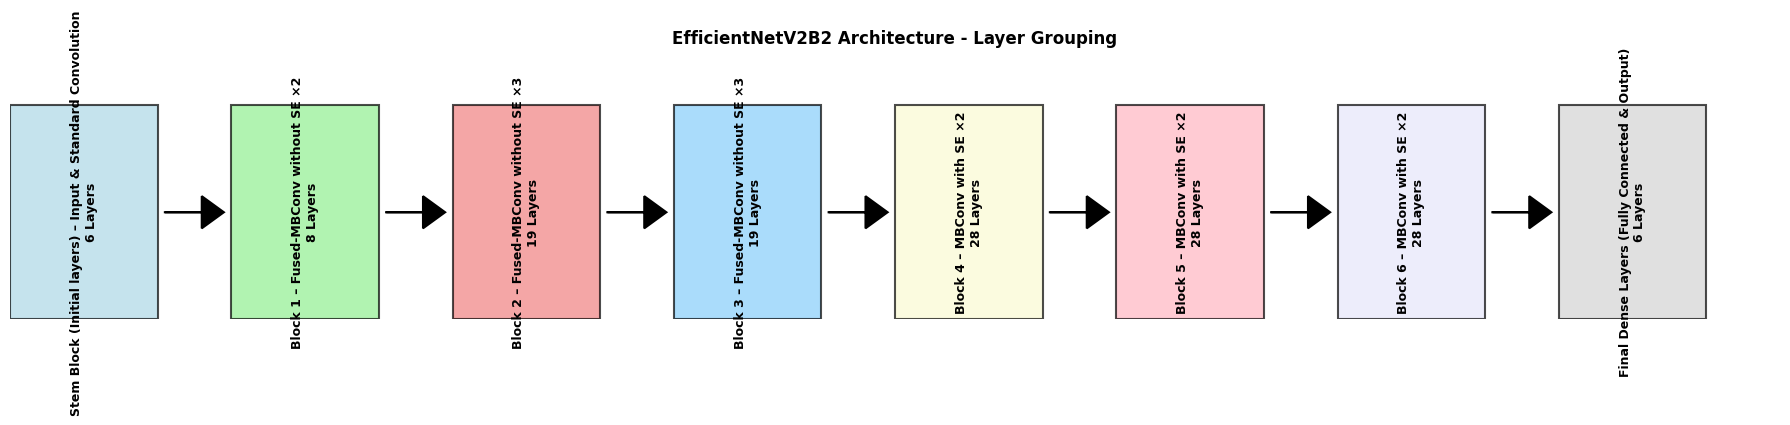

In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Define grouped layers
layer_groups = {
    "Stem Block (Initial layers) – Input & Standard Convolution": [
        "input_layer_1", "rescaling_1", "normalization_1",
        "stem_conv", "stem_bn", "stem_activation"
    ],
    "Block 1 – Fused-MBConv without SE ×2": [
        "block1a_project_conv", "block1a_project_bn", "block1a_project_activation",
        "block1b_project_conv", "block1b_project_bn", "block1b_project_activation",
        "block1b_drop", "block1b_add"
    ],
    "Block 2 – Fused-MBConv without SE ×3": [
        "block2a_expand_conv", "block2a_expand_bn", "block2a_expand_activation",
        "block2a_project_conv", "block2a_project_bn",
        "block2b_expand_conv", "block2b_expand_bn", "block2b_expand_activation",
        "block2b_project_conv", "block2b_project_bn", "block2b_drop", "block2b_add",
        "block2c_expand_conv", "block2c_expand_bn", "block2c_expand_activation",
        "block2c_project_conv", "block2c_project_bn", "block2c_drop", "block2c_add"
    ],
    "Block 3 – Fused-MBConv without SE ×3": [
        "block3a_expand_conv", "block3a_expand_bn", "block3a_expand_activation",
        "block3a_project_conv", "block3a_project_bn",
        "block3b_expand_conv", "block3b_expand_bn", "block3b_expand_activation",
        "block3b_project_conv", "block3b_project_bn", "block3b_drop", "block3b_add",
        "block3c_expand_conv", "block3c_expand_bn", "block3c_expand_activation",
        "block3c_project_conv", "block3c_project_bn", "block3c_drop", "block3c_add"
    ],
    "Block 4 – MBConv with SE ×2": [
        "block4a_expand_conv", "block4a_expand_bn", "block4a_expand_activation",
        "block4a_dwconv2", "block4a_bn", "block4a_activation",
        "block4a_se_squeeze", "block4a_se_reshape", "block4a_se_reduce", "block4a_se_expand", "block4a_se_excite",
        "block4a_project_conv", "block4a_project_bn",
        "block4b_expand_conv", "block4b_expand_bn", "block4b_expand_activation",
        "block4b_dwconv2", "block4b_bn", "block4b_activation",
        "block4b_se_squeeze", "block4b_se_reshape", "block4b_se_reduce", "block4b_se_expand", "block4b_se_excite",
        "block4b_project_conv", "block4b_project_bn", "block4b_drop", "block4b_add"
    ],
    "Block 5 – MBConv with SE ×2": [
        "block5a_expand_conv", "block5a_expand_bn", "block5a_expand_activation",
        "block5a_dwconv2", "block5a_bn", "block5a_activation",
        "block5a_se_squeeze", "block5a_se_reshape", "block5a_se_reduce", "block5a_se_expand", "block5a_se_excite",
        "block5a_project_conv", "block5a_project_bn",
        "block5b_expand_conv", "block5b_expand_bn", "block5b_expand_activation",
        "block5b_dwconv2", "block5b_bn", "block5b_activation",
        "block5b_se_squeeze", "block5b_se_reshape", "block5b_se_reduce", "block5b_se_expand", "block5b_se_excite",
        "block5b_project_conv", "block5b_project_bn", "block5b_drop", "block5b_add"
    ],
    "Block 6 – MBConv with SE ×2": [
        "block6a_expand_conv", "block6a_expand_bn", "block6a_expand_activation",
        "block6a_dwconv2", "block6a_bn", "block6a_activation",
        "block6a_se_squeeze", "block6a_se_reshape", "block6a_se_reduce", "block6a_se_expand", "block6a_se_excite",
        "block6a_project_conv", "block6a_project_bn",
        "block6b_expand_conv", "block6b_expand_bn", "block6b_expand_activation",
        "block6b_dwconv2", "block6b_bn", "block6b_activation",
        "block6b_se_squeeze", "block6b_se_reshape", "block6b_se_reduce", "block6b_se_expand", "block6b_se_excite",
        "block6b_project_conv", "block6b_project_bn", "block6b_drop", "block6b_add"
    ],
    "Final Dense Layers (Fully Connected & Output)": [
        "top_conv", "top_bn", "top_activation", "avg_pool", "top_dropout",
        "predictions (Final Softmax Layer)"
    ]
}

# Plotting
fig, ax = plt.subplots(figsize=(18, 4))
x_offset = 0
colors = ["lightblue", "lightgreen", "lightcoral", "lightskyblue", "lightgoldenrodyellow",
          "lightpink", "lavender", "lightgray"]

for i, (group_name, layers) in enumerate(layer_groups.items()):
    group_width = 2  # Fixed width for each block
    rect = patches.Rectangle((x_offset, 0), group_width, 2, linewidth=1.5,
                             edgecolor='black', facecolor=colors[i % len(colors)], alpha=0.7)
    ax.add_patch(rect)

    # Add text label
    ax.text(x_offset + group_width / 2, 1, f"{group_name}\n{len(layers)} Layers",
            ha='center', va='center', fontsize=9, fontweight='bold', rotation=90)

    # Add arrows between blocks
    if i < len(layer_groups) - 1:
        ax.arrow(x_offset + group_width + 0.1, 1, 0.5, 0, head_width=0.3, head_length=0.3,
                 fc="black", ec="black", linewidth=1.5)

    x_offset += group_width + 1  # spacing between blocks

ax.set_xlim(0, x_offset)
ax.set_ylim(0, 2.5)
ax.set_xticks([])
ax.set_yticks([])
ax.set_frame_on(False)

plt.title("EfficientNetV2B2 Architecture - Layer Grouping", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


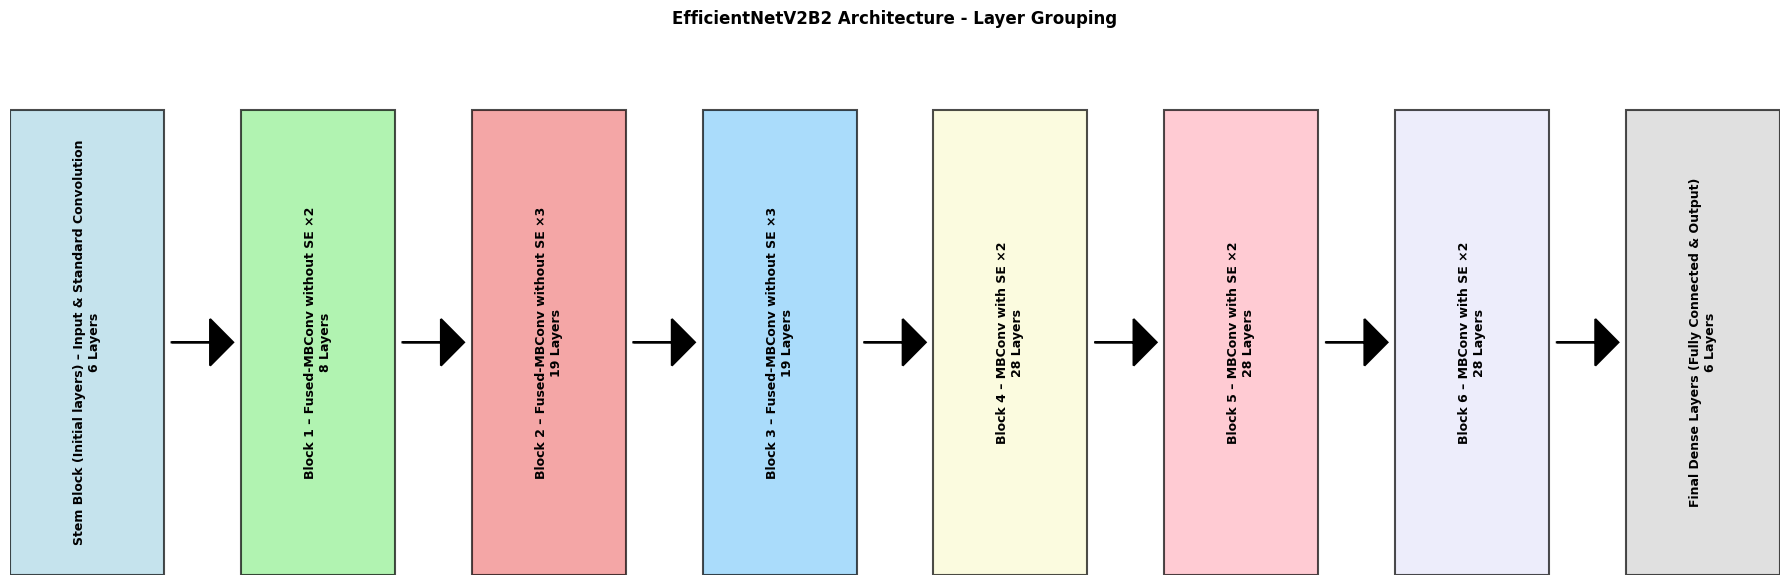

In [15]:
fig, ax = plt.subplots(figsize=(18, 6))  # Increased vertical size
x_offset = 0
rect_height = 3  # Increased from 2 to 3

for i, (group_name, layers) in enumerate(layer_groups.items()):
    group_width = 2
    rect = patches.Rectangle((x_offset, 0), group_width, rect_height, linewidth=1.5,
                             edgecolor='black', facecolor=colors[i % len(colors)], alpha=0.7)
    ax.add_patch(rect)

    # Adjust label to vertical center
    ax.text(x_offset + group_width / 2, rect_height / 2, f"{group_name}\n{len(layers)} Layers",
            ha='center', va='center', fontsize=9, fontweight='bold', rotation=90)

    # Adjust arrow position
    if i < len(layer_groups) - 1:
        ax.arrow(x_offset + group_width + 0.1, rect_height / 2, 0.5, 0,
                 head_width=0.3, head_length=0.3, fc="black", ec="black", linewidth=1.5)

    x_offset += group_width + 1

ax.set_xlim(0, x_offset-1)
ax.set_ylim(0, rect_height + 0.5)  # Adjust to match new height
ax.set_xticks([])
ax.set_yticks([])
ax.set_frame_on(False)

plt.title("EfficientNetV2B2 Architecture - Layer Grouping", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
